In [1]:
from collections.abc import Callable
from typing import Any

import dnnlpy
import dnnlpy.nn as dnn
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as utils
import torchinfo
import torchmetrics.classification as metrics
import torchvision.datasets as datasets
import torchvision.transforms.v2 as v2
from torch import Tensor, inference_mode

dnnlpy.set_matplotlib_format('svg')
print("successfully loaded!")

successfully loaded!


In [2]:
"""
    从卷积层到卷积块
"""

block = nn.Sequential(
    dnn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    dnn.MaxPool2d(kernel_size=2, stride=2)
)

x = torch.randn(16, 3, 28, 28)
y = block(x)
print("Input shape: ", x.shape)
print("Output shape: ", y.shape)

Input shape:  torch.Size([16, 3, 28, 28])
Output shape:  torch.Size([16, 16, 14, 14])


In [3]:
"""
CNN中的通道和空间尺寸
     - 浅层保留较为清晰的空间位置
     - 深层使用更多的描述更丰富的语义
     - 下采样较少计算量,并让深层单位看到最大的输入区域
"""

features = nn.Sequential(
    dnn.Conv2d(3, 16, kernel_size=3, padding=1),
    dnn.ReLU(),
    dnn.MaxPool2d(kernel_size=2, stride=2),
    dnn.Conv2d(16, 32, kernel_size=3, padding=1),
    dnn.ReLU(),
    dnn.MaxPool2d(kernel_size=2, stride=2),

)

x = torch.randn(16, 3, 28, 28)
y = features(x)
print("Input shape: ", x.shape)
print("Feature shape: ", y.shape)


Input shape:  torch.Size([16, 3, 28, 28])
Feature shape:  torch.Size([16, 32, 7, 7])


In [7]:
"""
特征提取器和分类头
    - 特征提取器:有卷积,激活函数和下采样操作构成
    - 分类头: 把最终的特征转换成类别logits
"""

x = torch.randn(4, 32, 7, 7)
y = x.flatten()

print("Input shape: ", x.shape)
print("After  flatten: ", y.shape)

pooled = F.adaptive_avg_pool2d(x, (1, 1))
feature_vector = pooled.flatten()

print("Feature map: ", x.shape)
print("After global  average pooling: ", pooled.shape)
print("Feature vector: ", feature_vector.shape)



Input shape:  torch.Size([4, 32, 7, 7])
After  flatten:  torch.Size([6272])
Feature map:  torch.Size([4, 32, 7, 7])
After global  average pooling:  torch.Size([4, 32, 1, 1])
Feature vector:  torch.Size([128])


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels: int = 1, num_channels: int = 3):
        super().__init__()
        self.num_channels = num_channels
        self.features = nn.Sequential(
            dnn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            dnn.ReLU(),
            dnn.MaxPool2d(kernel_size=2, stride=2),
            dnn.Conv2d(16, 32, kernel_size=3, padding=1),
            dnn.ReLU(),
            dnn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.flatten = dnn.Flatten()
        self.pool = dnn.AdaptiveAvgPool2d(1)
        self.classifier = dnn.Linear(32, num_channels)

    def forward(self, X: Tensor) -> Tensor:
        x = self.features(X)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(in_channels=3, num_channels=3)

x = torch.randn(16, 3, 28, 28)
logits = model(x)

print(model)
print("Input shape: ", x.shape)
print("Output shape: ", logits.shape)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1, 1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1, 1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)
Input shape:  torch.Size([16, 3, 28, 28])
Output shape:  torch.Size([16, 3])


In [10]:
"""
逐层检查张量形状
"""
summary = torchinfo.summary(model, input_size=(16, 3, 28, 28))
print(summary)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [16, 3]                   --
├─Sequential: 1-1                        [16, 32, 7, 7]            --
│    └─Conv2d: 2-1                       [16, 16, 28, 28]          448
│    └─ReLU: 2-2                         [16, 16, 28, 28]          --
│    └─MaxPool2d: 2-3                    [16, 16, 14, 14]          --
│    └─Conv2d: 2-4                       [16, 32, 14, 14]          4,640
│    └─ReLU: 2-5                         [16, 32, 14, 14]          --
│    └─MaxPool2d: 2-6                    [16, 32, 7, 7]            --
├─AdaptiveAvgPool2d: 1-2                 [16, 32, 1, 1]            --
├─Flatten: 1-3                           [16, 32]                  --
├─Linear: 1-4                            [16, 3]                   99
Total params: 5,187
Trainable params: 5,187
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 20.17
Input size (MB): 0.15
Forward/backward pas

In [13]:
"""
训练一个完整的CNN
"""
root = dnnlpy.get_data_root()
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train_ds = datasets.MNIST(root=root, train=True, transform=transform, download=True)
train_ds, val_ds = utils.random_split(train_ds, lengths=[50000, 10000])
test_ds = datasets.MNIST(root=root, train=False, transform=transform, download=True)

train_dl = utils.DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = utils.DataLoader(test_ds, batch_size=128, shuffle=False)
val_dl = utils.DataLoader(val_ds, batch_size=128, shuffle=False)

images, labels = next(iter(train_dl))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

device = dnnlpy.get_default_device()

model = SimpleCNN(in_channels=1, num_channels=10).to(device)

optimizer = dopt.AdamW(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

trainer = dnnlpy.Trainer(max_epochs=10, device=device)

trainer.fit(model=model, train_dataloader=train_dl, val_dataloader=val_dl, loss_fn=loss_fn, optimizer=optimizer,
            train_metrics={'acc': metrics.MulticlassAccuracy(model.num_channels)},
            val_metrics={'acc': metrics.MulticlassAccuracy(model.num_channels)})



Image batch: torch.Size([64, 1, 28, 28])
Label batch: torch.Size([64])
Training on cpu...
Epoch [ 1/10] | loss: 2.0059 | acc: 0.2614 | val_loss: 1.7090 | val_acc: 0.4028
Epoch [ 2/10] | loss: 1.4148 | acc: 0.5179 | val_loss: 1.1972 | val_acc: 0.6363
Epoch [ 3/10] | loss: 1.0562 | acc: 0.6600 | val_loss: 0.9399 | val_acc: 0.7046
Epoch [ 4/10] | loss: 0.8347 | acc: 0.7453 | val_loss: 0.7723 | val_acc: 0.7538
Epoch [ 5/10] | loss: 0.6900 | acc: 0.7951 | val_loss: 0.6454 | val_acc: 0.7988
Epoch [ 6/10] | loss: 0.5831 | acc: 0.8291 | val_loss: 0.5442 | val_acc: 0.8400
Epoch [ 7/10] | loss: 0.5110 | acc: 0.8505 | val_loss: 0.4863 | val_acc: 0.8557
Epoch [ 8/10] | loss: 0.4556 | acc: 0.8645 | val_loss: 0.4264 | val_acc: 0.8759
Epoch [ 9/10] | loss: 0.4152 | acc: 0.8779 | val_loss: 0.3999 | val_acc: 0.8817
Epoch [10/10] | loss: 0.3839 | acc: 0.8855 | val_loss: 0.3688 | val_acc: 0.8891


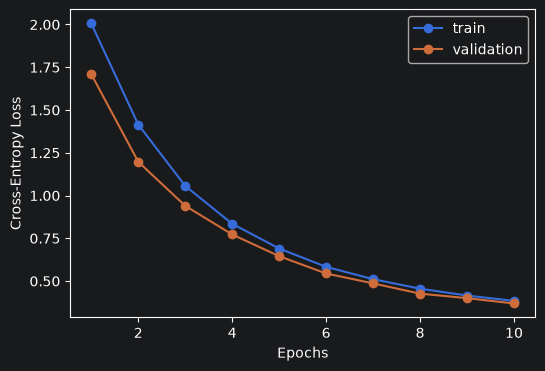

In [14]:
epochs = [row['epoch'] for row in trainer.history]
loss = [row['loss'] for row in trainer.history]
val_loss = [row['val_loss'] for row in trainer.history]

fig = plt.figure(1, figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(epochs, loss, marker='o')
ax.plot(epochs, val_loss, marker='o')
ax.set_xlabel("Epochs")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(['train', 'validation'])
plt.show()

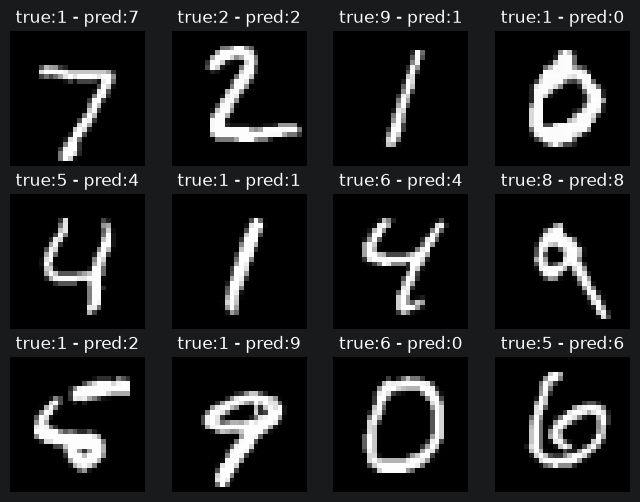

In [15]:
model.eval()
images, label = next(iter(test_dl))

with torch.inference_mode():
    logits = model(images.to(device))
    preds = logits.argmax(dim=1).cpu()

fig = plt.figure(2, figsize=(8, 6))
axes = fig.subplots(3, 4)
z = zip(axes.flat, images[:12], labels[:12], preds[:12], strict=True)
for ax, image, label, pred in z:
    true_label = label.item()
    pred_label = pred.item()
    ax.imshow(image.squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f"true:{true_label} - pred:{pred_label}")
plt.show()



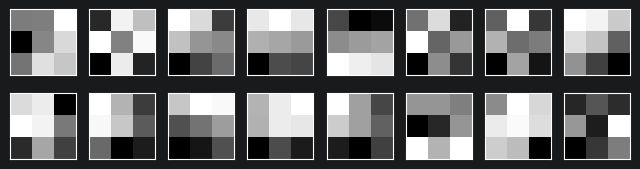

In [17]:
"""
CNN 学习到仍然还是可学习参数
"""

conv = model.features[0]
assert isinstance(conv, dnn.Conv2d)
kernels = conv.weight.detach().cpu()
fig =  plt.figure(3,figsize=(8, 2))
axes = fig.subplots(2, 8)
for ax,kernel in zip(axes.flat, kernels,strict=True):
    ax.imshow(kernel[0], cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

